In [1]:
using DataFrames, Distributions, Plots, StatsBase, StatsPlots, Random, Serialization, Plots.PlotMeasures, CSV, JSON, Feather

In [2]:
function gini(x)
    #=
    Compute the Gini coefficient
    =#
    n = length(x)
    x = sort(x)
    (2 * sum(x .* (1:1:n))/sum(x) - (n+1)) / n
end

function reset_data(N,M)
    #=
    Create the initial distribution
    N = 1000 # number of agents
    M = 10 # initial wealth
    =#
    wealth = repeat([M],N)
    id = Vector(1:N)
    win = zeros(N)
    Cases = DataFrame(id = id, wealth = wealth, win = win)
    Cases.wealth = convert(Array{Float64}, Cases.wealth)
    return Cases
end

function generate_vals(phi::Float64, l::Int64, N::Int64)
    a = l * (phi + 1) / 2  # (C_t, I_t) = (1, 1)
    b = l - a  # (C_t, I_t) = (1, 0)
    c = l - a  # (C_t, I_t) = (0, 1)
    d = a  # (C_t, I_t) = (0, 0)

    p = [a, b, c, d] ./ (2 * l)
    dist = [[1,1], [1,0], [0,1], [0,0]]

    val = [dist[rand(Categorical(p))] for _ in 1:(N ÷ 2)]
    d_vals = [x[1] for x in val]
    e_vals = [x[2] for x in val]

    return d_vals, e_vals
end

function exchange_Unify(init::DataFrame, ω_e::Float64, ω_i::Float64, α::Float64,Φ::Float64,l::Int64)
    N = Int(nrow(init))
    pairs = reshape(shuffle(1:N), N ÷ 2, 2)  # form random pairs

    val = generate_vals(Φ,l,N)

    d_e = val[1]  # competition outcomes C_t
    d_i = val[2]  # investment outcomes I_t

    c1_factors = 1 .- ω_e .* (1 .- α) .* (1 .- d_e) .+ ω_i .* α .* d_i
    c2_factors = ω_e .* (1 .- α) .* d_e
    c3_factors = ω_e .* (1 .- α) .* (1 .- d_e)
    c4_factors = 1 .- ω_e .* (1 .- α) .* d_e .+ ω_i .* α .* (1 .- d_i)

    wealth1 = init[pairs[:, 1], :wealth]
    wealth2 = init[pairs[:, 2], :wealth]

    new_wealth1 = c1_factors .* wealth1 .+ c2_factors .* wealth2
    new_wealth2 = c3_factors .* wealth1 .+ c4_factors .* wealth2

    init[pairs[:, 1], :wealth] .= new_wealth1
    init[pairs[:, 2], :wealth] .= new_wealth2

    return init
end

function DataLast(init, T, exchange_func)
    """
    init: initial data
    T: number of time steps
    exchange_func: exchange function to apply
    """
    for j in 1:T
        init = init[sample(1:nrow(init), nrow(init), replace = false), :]
        exchange_func(init)
    end
    return init[:, :2]  # return the wealth column
end

# Sort each trial's incomes in ascending order and average them by rank across the trials
function compute_sorted_means(results)
    sorted_means = DataFrame(ω=Float64[], α=Float64[], mean_incomes=Vector{Float64}[])

    for row in eachrow(results)
        incomes = row[:incomes]
        sorted_incomes = [sort(income) for income in incomes]
        mean_incomes = [mean([sorted_incomes[j][i] for j in 1:length(sorted_incomes)]) for i in 1:length(sorted_incomes[1])]
        push!(sorted_means, (row[:ω], row[:α], mean_incomes))
    end

    return sorted_means
end

compute_sorted_means (generic function with 1 method)

## Trial

In [3]:
margin = 500
Φ = 0.0 # no correlation between C_t and I_t (Eq. 8)
T = 100 # number of time steps
M = 10 # Money
N = 1000 # number of agents

ω = 0.3
init = reset_data(N, M)
α = 0.7

0.7

In [4]:
Random.seed!(2)

α_vals = 0.0:0.1:1.0
ω_vals = 0.1:0.1:0.9

results = DataFrame(ω=Float64[], α=Float64[], incomes=Vector{Float64}[])


for ω in ω_vals
    for α in α_vals

        init = reset_data(N, M)
        income_vec = DataLast(init, T, x -> exchange_Unify(x, ω, ω, α, Φ, margin))  # wealth at time T

        push!(results, (ω, α, income_vec))
    end
end


In [5]:
results

Row,ω,α,incomes
,Float64,Float64,Array…
1,0.1,0.0,"[9.27964, 7.92656, 19.8266, 4.35418, 8.27978, 11.2054, 8.58711, 8.93494, 10.8459, 9.13181 … 8.30384, 7.48538, 10.8483, 14.3916, 12.1073, 5.43736, 10.5482, 14.0951, 5.15353, 11.0961]"
2,0.1,0.1,"[18.1539, 9.55641, 21.7688, 12.1375, 15.545, 9.6406, 14.1925, 25.1128, 15.5361, 16.1483 … 15.6727, 15.6129, 16.1339, 19.0323, 15.8685, 14.5172, 15.1677, 13.3692, 13.2427, 18.95]"
3,0.1,0.2,"[28.8148, 37.2358, 15.5787, 28.4725, 14.5283, 30.679, 24.6736, 28.9906, 33.8634, 23.2761 … 39.823, 39.4976, 23.0948, 18.4125, 22.1008, 26.0599, 26.09, 30.032, 33.8965, 25.9736]"
4,0.1,0.3,"[60.2941, 71.6922, 37.3078, 27.5607, 60.0333, 53.72, 48.5356, 46.3735, 69.0681, 46.8244 … 47.71, 26.4962, 46.2157, 52.1237, 57.1079, 42.0854, 37.9475, 39.5768, 24.2987, 55.1644]"
5,0.1,0.4,"[83.1207, 91.5761, 98.7906, 86.1594, 60.3477, 84.6337, 98.5804, 75.3643, 42.6588, 70.8233 … 50.6805, 100.536, 78.2125, 79.2594, 66.0452, 99.7998, 113.221, 31.1635, 69.0813, 102.444]"
6,0.1,0.5,"[108.226, 142.175, 180.238, 189.721, 116.142, 135.477, 110.129, 111.85, 169.298, 134.618 … 131.34, 109.426, 168.453, 105.241, 114.703, 113.391, 127.342, 88.9627, 118.317, 82.8901]"
7,0.1,0.6,"[189.481, 174.303, 217.369, 114.217, 134.88, 260.096, 201.478, 298.234, 205.345, 149.667 … 262.364, 133.244, 125.753, 118.858, 252.686, 181.518, 184.526, 176.415, 250.754, 217.319]"
8,0.1,0.7,"[317.983, 532.07, 235.493, 422.173, 303.271, 454.284, 311.873, 249.886, 250.467, 359.904 … 330.0, 321.67, 315.471, 309.526, 407.966, 366.682, 134.375, 273.814, 292.764, 580.415]"
9,0.1,0.8,"[532.493, 362.845, 422.885, 501.204, 519.457, 777.928, 802.875, 487.329, 467.578, 455.66 … 367.789, 722.853, 647.349, 739.266, 448.376, 537.952, 526.128, 552.018, 353.625, 511.162]"


## Mean

In [6]:
Random.seed!(0)
margin = 500

Φ = 0.0

T = 10
M = 10
N = 1000
init = reset_data(N, M)
plt = plot()
pal = palette(:seaborn_colorblind)
c = 0

for k in (0.1:0.1:0.9)
    ω = k
    c += 1
    meanmean = Float64[]
    meanerror = Float64[]

    for j in (0.0:0.1:1.0)
        α = j
        mean_vals = [mean(DataLast(init, T, x -> exchange_Unify(x, ω, ω, α, Φ, margin))) for _ in 1:100]
        append!(meanmean, mean(mean_vals))
        append!(meanerror, std(mean_vals))
    end
    plot!(plt,(0.0:0.1:1.0),meanmean,grid=false,yerror=meanerror,
    markerstrokecolor=:auto, xlabel = "α",ylabel = "Mean",
    lc=pal[c],label = "ω=$ω", legend = :outertopright)
end


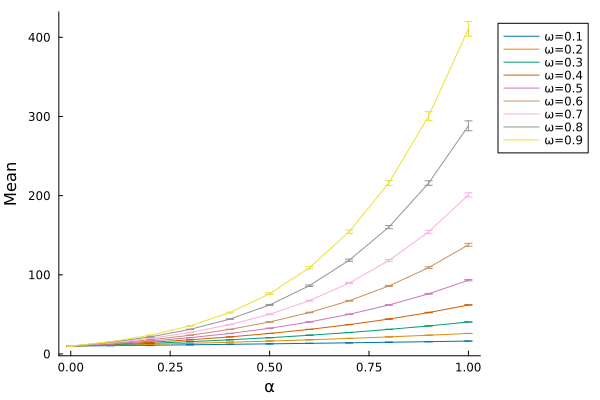

In [7]:
savefig(plt, joinpath(@__DIR__, "..", "..", "results", "Fig2a_mean.pdf"))
plt

## Gini

In [8]:
Random.seed!(0)
margin = 500

Φ = 0.0

T = 100
M = 10
N = 1000
init = reset_data(N, M)
plt = plot()
pal = palette(:seaborn_colorblind)
c = 0

for k in (0.1:0.1:0.9)
    ω = k
    c += 1
    ginimean = Float64[]
    ginierror = Float64[]

    for j in (0.0:0.1:1.0)
        α = j
        gini_vals = [gini(DataLast(init, T, x -> exchange_Unify(x, ω, ω, α, Φ, margin))) for _ in 1:100]
        append!(ginimean, mean(gini_vals))
        append!(ginierror, std(gini_vals))
    end
    plot!(plt,(0.0:0.1:1.0),ginimean,grid=false,yerror=ginierror,
    markerstrokecolor=:auto, xlabel = "α",ylabel="Gini Coefficient",
    lc=pal[c],label = "ω=$ω", legend = :outertopright)
end


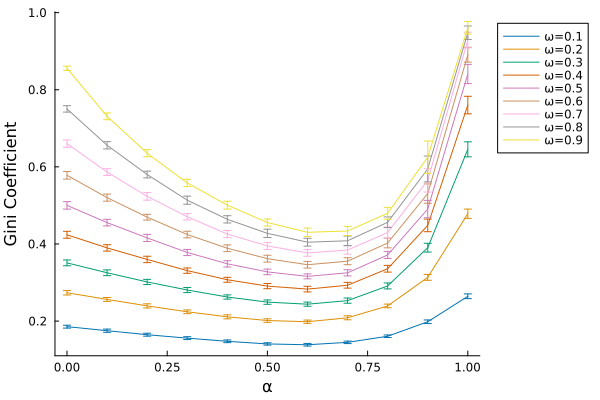

In [9]:
savefig(plt, joinpath(@__DIR__, "..", "..", "results", "Fig2b_gini.pdf"))
plt

## Gini convergence

In [11]:
Random.seed!(0)
T = 100
M = 10
N = 1000
margin = 500

ginis = []
params = []

for ω in 0.1:0.1:0.9
    for α in 0.0:0.1:1.0
        gini_series = Float64[]
        init = reset_data(N, M)
        for t in 1:T
            init = init[sample(1:nrow(init), nrow(init), replace = false), :]
            z = exchange_Unify(init, ω, ω, α, 0.0, margin)
            push!(gini_series, gini(z[:, :2]))
        end

        push!(ginis, gini_series)
        push!(params, "ω=$ω, α=$α")
    end
end


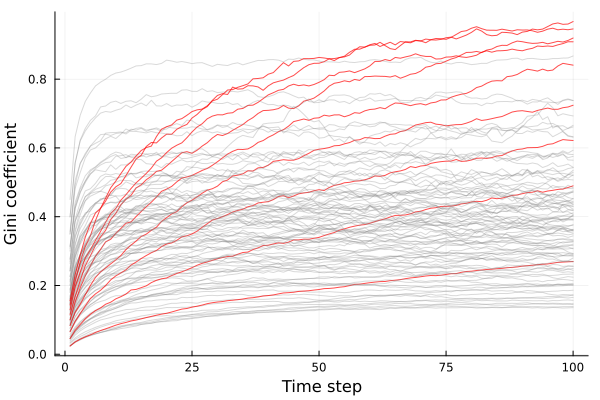

In [12]:
plot()
for i in 1:length(ginis)
    if occursin("α=1.0", params[i])
        plot!(1:T, ginis[i], legend=false, lw=1, alpha=0.7, color=:red)
    else
        plot!(1:T, ginis[i], legend=false, lw=1, alpha=0.3, color=:gray)
    end
end

xlabel!("Time step")
ylabel!("Gini coefficient")
savefig(joinpath(@__DIR__, "..", "..", "results", "Fig1_gini_convergence.pdf"))
current()

## Data Generate

In [13]:
Random.seed!(0)

α_vals = 0.0:0.1:1.0
ω_vals = 0.1:0.1:0.9

results = DataFrame(ω=Float64[], α=Float64[], incomes=Vector{Vector{Float64}}[])

num_simulations = 100

for ω in ω_vals
    for α in α_vals
        sim_results = Vector{Vector{Float64}}()

        for _ in 1:num_simulations
            init = reset_data(N, M)
            income_vec = DataLast(init, T, x -> exchange_Unify(x, ω, ω, α, Φ, margin))  # wealth at time T
            push!(sim_results, income_vec)
        end

        push!(results, (ω, α, sim_results))
    end
end

In [14]:
# Rank-wise mean across trials
sorted_means = compute_sorted_means(results)

Row,ω,α,mean_incomes
,Float64,Float64,Array…
1,0.1,0.0,"[2.41313, 2.82245, 3.06596, 3.23298, 3.36087, 3.47022, 3.56791, 3.66068, 3.73078, 3.79358 … 19.3738, 19.5837, 19.8518, 20.1144, 20.4219, 20.7605, 21.2501, 21.8355, 22.7757, 24.6689]"
2,0.1,0.1,"[4.59332, 5.20949, 5.53615, 5.79462, 6.01166, 6.18403, 6.32342, 6.44615, 6.57415, 6.68946 … 30.9673, 31.2405, 31.5994, 32.0217, 32.4887, 33.1026, 33.8463, 34.8271, 36.0903, 38.3903]"
3,0.1,0.2,"[7.80747, 9.06952, 9.76519, 10.2932, 10.67, 10.9167, 11.2086, 11.4264, 11.5901, 11.8021 … 49.6206, 50.0821, 50.6637, 51.2707, 52.0993, 52.9042, 54.1343, 55.5331, 57.6957, 61.8147]"
4,0.1,0.3,"[14.6408, 16.5642, 17.4587, 18.1353, 18.7279, 19.2461, 19.6551, 19.964, 20.3299, 20.6096 … 79.0058, 79.99, 80.9455, 81.8601, 83.0577, 84.283, 85.863, 88.3009, 91.6797, 97.4223]"
5,0.1,0.4,"[26.0101, 28.6624, 30.3434, 31.4974, 32.3838, 33.1439, 33.8297, 34.4379, 34.9915, 35.5147 … 125.817, 127.002, 128.394, 129.865, 131.943, 134.331, 136.835, 140.324, 145.145, 154.102]"
6,0.1,0.5,"[46.4174, 49.9818, 52.7476, 54.3668, 55.9604, 57.0536, 58.1245, 59.1258, 59.9275, 60.6012 … 201.766, 203.418, 205.499, 207.808, 210.556, 213.75, 218.161, 223.596, 230.886, 245.89]"
7,0.1,0.6,"[78.06, 85.2295, 88.7473, 91.7335, 94.0602, 95.8779, 97.2989, 98.6384, 99.9252, 101.075 … 328.732, 331.666, 335.032, 338.933, 343.6, 348.344, 355.985, 364.536, 379.045, 405.981]"
8,0.1,0.7,"[128.592, 139.107, 145.126, 149.521, 152.533, 155.273, 157.956, 160.283, 162.105, 163.874 … 554.369, 560.336, 566.0, 574.081, 581.91, 593.276, 609.036, 627.276, 653.187, 702.307]"
9,0.1,0.8,"[199.597, 211.966, 221.868, 228.595, 234.607, 238.916, 242.825, 245.816, 248.394, 251.333 … 964.94, 977.766, 992.055, 1006.84, 1023.57, 1046.16, 1073.28, 1104.53, 1160.93, 1268.11]"


In [15]:
# Convert to JSON strings before saving
transform!(sorted_means, :mean_incomes => ByRow(JSON.json) => :mean_incomes)

data_path = joinpath(@__DIR__, "..", "..", "data", "sorted_mean_incomes_99.feather")


Feather.write(data_path, sorted_means);